# CIFAR-10 Parallel Training on Kaggle (1 GPU vs 2 GPU DDP)
This notebook is structured to support the assignment rubric. It runs a single-worker baseline, a 2-GPU DDP configuration, and then computes rubric-aligned metrics such as speedup, efficiency, communication fraction, and accuracy gap.

List all the team members BITS ID ,Name along with % of contribution in this assignment:
1. 2025AE05975  - Bala Gangadhara Tilak - 100%
2. 2025AE05815  - GOHIL KUNAL DEEPAK VANITA - 100%
3. 2025AE05780  - LAAVAAN J - 100%

## 1. Verify hardware
These checks are important for measurement quality. The experiment is valid only if Kaggle has attached two GPUs.

In [1]:
!nvidia-smi

Wed Apr 22 16:28:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)}')

CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Run the 1-GPU baseline
This run establishes the single-worker reference time T1 required for speedup and efficiency.

In [3]:
!CUDA_VISIBLE_DEVICES=0 python /kaggle/input/datasets/mbgtilak/cifar10/source/train_ddp_kaggle.py --data-dir /kaggle/working/data --output-dir /kaggle/working/outputs --epochs 30 --batch-size 128 --workers 4 --lr 0.1 --amp --run-name resnet18_1gpu_bs128

100%|████████████████████████████████████████| 170M/170M [00:05<00:00, 31.6MB/s]
/kaggle/input/datasets/mbgtilak/cifar10/source/train_ddp_kaggle.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=args.amp)
/kaggle/input/datasets/mbgtilak/cifar10/source/train_ddp_kaggle.py:225: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=args.amp):
epoch=1 step=100/391 loss=2.1618
epoch=1 step=200/391 loss=2.0381
epoch=1 step=300/391 loss=1.7738
[epoch 01] acc=33.55% time=46.59s throughput=1073.1 img/s comm_frac=0.034
epoch=2 step=100/391 loss=1.5342
epoch=2 step=200/391 loss=1.3830
epoch=2 step=300/391 loss=1.4836
[epoch 02] acc=47.21% time=19.57s throughput=2555.6 img/s comm_frac=0.075
epoch=3 step=100/391 loss=1.2424
epoch=3 step=200/391 loss=1.2535
epoch=3 

## 3. Run the 2-GPU DDP configuration
This run keeps the per-GPU batch size fixed and measures the scaling behavior of synchronous data parallelism.

In [4]:
!torchrun --standalone --nproc_per_node=2 /kaggle/input/datasets/mbgtilak/cifar10/source/train_ddp_kaggle.py --data-dir /kaggle/working/data --output-dir /kaggle/working/outputs --epochs 30 --batch-size 128 --workers 4 --lr 0.1 --amp --run-name resnet18_2gpu_bs128

W0422 16:42:04.339000 155 torch/distributed/run.py:852] 
W0422 16:42:04.339000 155 torch/distributed/run.py:852] *****************************************
W0422 16:42:04.339000 155 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0422 16:42:04.339000 155 torch/distributed/run.py:852] *****************************************
[W422 16:42:04.693835169 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W422 16:42:07.900500248 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W422 16:42:07.909705919 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
/kaggle/input/datasets/mbgtilak/cifar10/source/train_ddp_kaggle.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `

## 4. Analyze the results
The analysis script computes average epoch time, speedup, efficiency, communication fraction, and accuracy gap directly from the per-epoch logs.

In [5]:
!python /kaggle/input/datasets/mbgtilak/cifar10/source/analyze_results.py --baseline /kaggle/working/outputs/resnet18_1gpu_bs128/epoch_metrics.csv --parallel /kaggle/working/outputs/resnet18_2gpu_bs128/epoch_metrics.csv --output /kaggle/working/outputs/analysis_summary.json

{
  "avg_epoch_time_1gpu_sec": 22.357,
  "avg_epoch_time_2gpu_sec": 14.4983,
  "speedup_2gpu_vs_1gpu": 1.542,
  "parallel_efficiency_percent": 77.1,
  "avg_comm_fraction_2gpu": 0.067,
  "best_acc_1gpu": 0.9333,
  "best_acc_2gpu": 0.9222,
  "accuracy_gap": 0.0111
}


In [6]:
import json
with open('/kaggle/working/outputs/analysis_summary.json', 'r') as f:
    summary = json.load(f)
summary

{'avg_epoch_time_1gpu_sec': 22.357,
 'avg_epoch_time_2gpu_sec': 14.4983,
 'speedup_2gpu_vs_1gpu': 1.542,
 'parallel_efficiency_percent': 77.1,
 'avg_comm_fraction_2gpu': 0.067,
 'best_acc_1gpu': 0.9333,
 'best_acc_2gpu': 0.9222,
 'accuracy_gap': 0.0111}

## 5. Generate report-ready plots
The revised plotting script includes accuracy vs training time, which aligns better with the assignment brief than accuracy vs epoch alone.

In [7]:
!python /kaggle/input/datasets/mbgtilak/cifar10/source/plot_results.py --baseline /kaggle/working/outputs/resnet18_1gpu_bs128/epoch_metrics.csv --parallel /kaggle/working/outputs/resnet18_2gpu_bs128/epoch_metrics.csv --output-dir /kaggle/working/outputs/plots

accuracy_vs_epoch.png


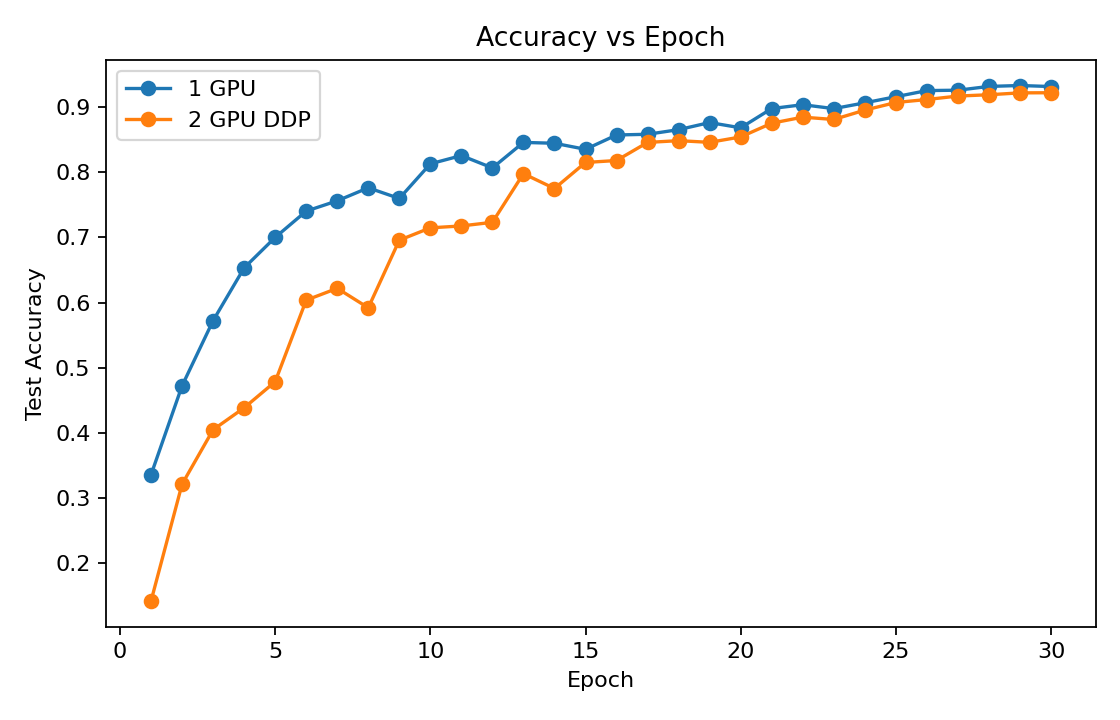

comm_fraction.png


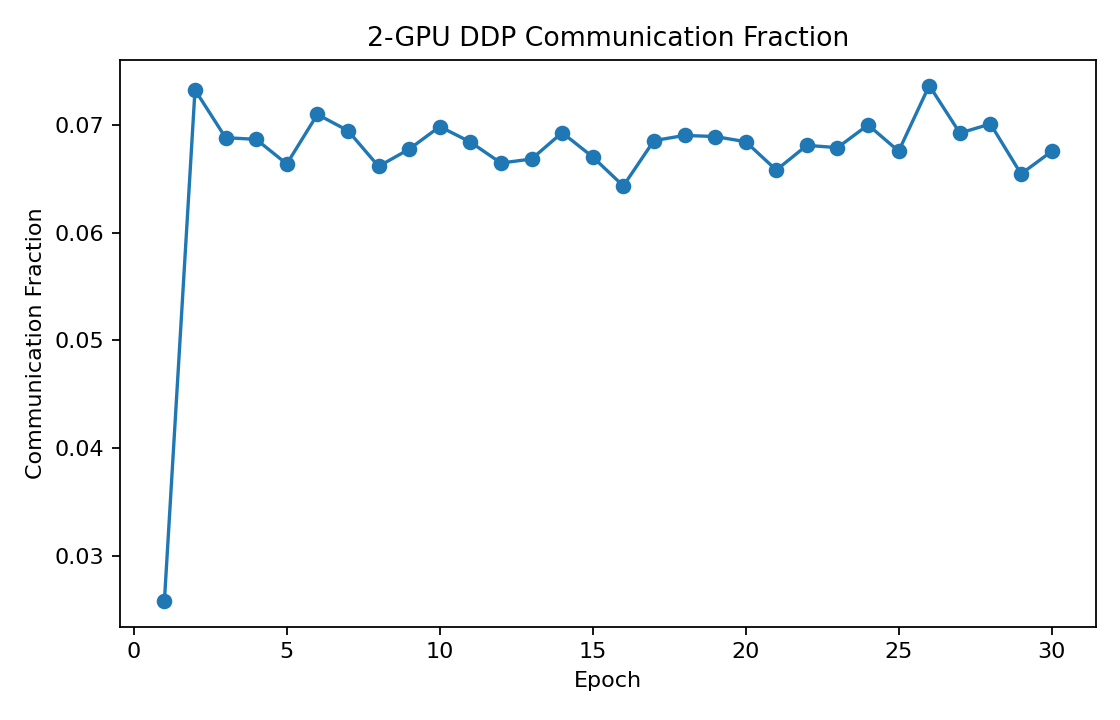

epoch_time_vs_epoch.png


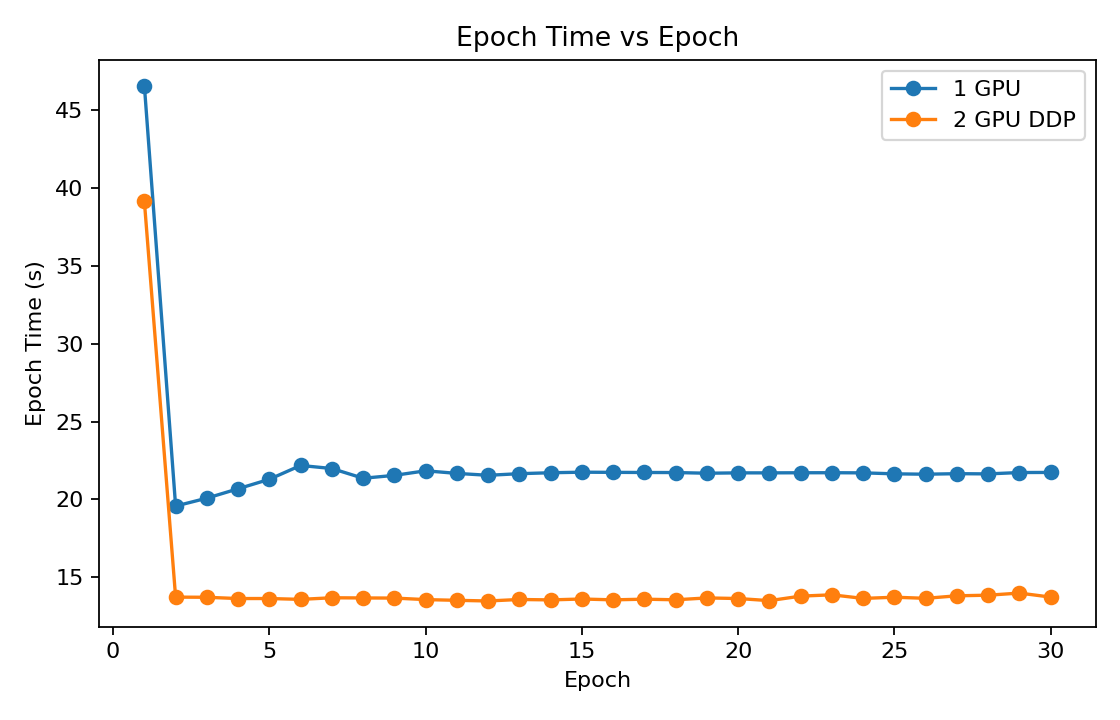

In [8]:
import os
from IPython.display import Image, display
for name in sorted(os.listdir('/kaggle/working/outputs/plots')):
    print(name)
    display(Image(filename=f'/kaggle/working/outputs/plots/{name}'))

## 6. 📊 Performance Metrics Evaluation (Formal Analysis)

This section evaluates the distributed training system using the required performance metrics as defined in the assignment.

## ***1. Speedup***

Speedup measures how much faster the parallel system performs compared to the single-GPU baseline.

$$
S(N) = \frac{T_1}{T_N}
$$

Where:  
- $T_1$ = total training time using 1 GPU  
- $T_N$ = total training time using $N$ GPUs  

Using measured values:

$$
S(2) = \frac{681.94}{450.39} = 1.542
$$

**Interpretation:**  
The system achieves a **1.54× speedup** when scaling from 1 GPU to 2 GPUs. This is sub-linear compared to the ideal speedup of 2×, primarily due to communication and synchronization overhead.

---

## ***2. Parallel Efficiency***

Parallel efficiency measures how effectively the additional GPU resources are utilized.
$$
E(N)= \frac{S(N)}{N}×100%
$$

$$
E(2)= \frac{1.542}{2}×100=77.1%
$$
Interpretation:
The system achieves 77.1% efficiency, indicating reasonably good scaling. The gap from 100% reflects overheads such as gradient synchronization and coordination between GPUs.

## ***3. Communication Cost***

Communication cost represents the fraction of time spent in synchronization (e.g., all-reduce operations).

$$
\text{Communication Fraction} = \frac{\text{Synchronization Time}}{\text{Total Step Time}}
$$

Measured value:

$$
\approx 0.067 \; (\text{or } 6.7\%)
$$

Interpretation:
Approximately 6.7% of total training time is spent in communication. This indicates that the workload is predominantly compute-bound, which is favorable for parallel efficiency.

## ***4. Response Time***

Response time is defined as the wall-clock time per training epoch, including data loading, computation, and synchronization.

Measured values:

1 GPU: 22.36 seconds

2 GPUs: 14.50 seconds

Interpretation:
The reduction in response time demonstrates that parallel execution improves training throughput and reduces per-epoch runtime.

## ***5. Accuracy Gap***

Accuracy gap measures the difference in model performance between single-GPU and multi-GPU training.

Accuracy Gap=Acc
1GPU
	​
−Acc
2GPU
	​
    
=0.9333−0.9222=0.0111(1.11%)

Interpretation:
The 1.11% decrease in accuracy is relatively small and is primarily attributed to the increased global batch size (128 → 256), rather than issues in the parallelization strategy.

---

## ***Summary***

| Metric              | Value           |
| ------------------- | --------------- |
| Speedup             | 1.542           |
| Parallel Efficiency | 77.1%           |
| Communication Cost  | 6.7%            |
| Response Time       | 22.36s → 14.50s |
| Accuracy Gap        | 1.11%           |

---

## **Overall Conclusion**

The system demonstrates effective parallelization with solid speedup and efficiency, low communication overhead, and minimal impact on model accuracy.
